# Part D — Mini Project: Encoding + Scaling + Distance Change

---

## 🎯 Project-এর Goal

একটি notebook-এ তিনটি জিনিস একসাথে দেখানো:
1. **Encoding** — nominal ও ordinal columns properly encode করা
2. **Scaling** — numeric columns-এ সঠিক scaler apply করা
3. **Distance change** — scaling-এর আগে ও পরে distance কীভাবে বদলায় দেখানো

**কোনো train-test split নেই, কোনো ML model নেই** — শুধু preprocessing।


---

## 🔍 প্রতিটি Step-এ কী করতে হবে?

| Step | কাজ |
|---|---|
| **Step 1** | Manually একটি DataFrame তৈরি করা — numeric, nominal ও ordinal column সহ |
| **Step 2** | Preprocessing plan ঠিক করা — কোন column-এ কী করব |
| **Step 3** | `ColumnTransformer` দিয়ে encoding ও scaling একসাথে apply করা |
| **Step 4** | দুটো numeric column নিয়ে distance before vs after scaling তুলনা করা |
| **Step 5** | 3–4 বাক্যে reflection লেখা |


---

## 🏆 এই Project থেকে কী অর্জন করব?

- এখন পর্যন্ত শেখা সব preprocessing skill একসাথে **একটি pipeline-এ** লাগাতে পারব।
- `ColumnTransformer` — real ML project-এ যেভাবে preprocessing করা হয় সেটা শিখব।
- Distance comparison দেখে **scaling কেন জরুরি** সেটা সংখ্যায় নিজেই prove করব।


---

## 🧠 কীভাবে চিন্তা করতে হবে?

### ColumnTransformer কী?

`ColumnTransformer` একটি sklearn tool যেটি দিয়ে বিভিন্ন column-এ **একসাথে আলাদা আলাদা transformation** apply করা যায়।

```
ColumnTransformer([
    ('ohe',      OneHotEncoder(),   ['City', 'Internet']),
    ('ordinal',  OrdinalEncoder(),  ['Education', 'Satisfaction']),
    ('robust',   RobustScaler(),    ['Income', 'Transactions']),
    ('minmax',   MinMaxScaler(),    ['Hours_Study', 'GPA', 'Temp_C'])
])
```

একটিমাত্র `.fit_transform()` call-এ সব column processed হয়।

### Distance comparison-এর logic:
- দুটো numeric column নিয়ে ৩টি row (P1, P2, P3) select করব।
- Unscaled → distance হিসাব।
- Standard Scaler দিয়ে scale → distance আবার হিসাব।
- Robust Scaler দিয়ে scale → distance আবার হিসাব।
- তিনটি তুলনা করে দেখব কোনটি বেশি meaningful।


## Step 0: Library Import করা

In [1]:
# Now we'll import all required libraries for this mini project
import numpy as np
import pandas as pd
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder,
                                   MinMaxScaler, RobustScaler, StandardScaler)
from sklearn.compose import ColumnTransformer
# Here we've imported everything needed — encoders, scalers, and ColumnTransformer.


`ColumnTransformer` — sklearn-এর `compose` module থেকে import করতে হয়।
এটি একাধিক transformer-কে একটি pipeline-এ জুড়ে দেয়।


---

## Step 1: DataFrame তৈরি করা

আমাদের custom dataset-এ থাকবে:
- **Numeric (3টি):** `Income_BDT`, `Hours_Study`, `GPA`
- **Nominal (2টি):** `City`, `Internet`
- **Ordinal (2টি):** `Education_Level`, `Satisfaction`


In [2]:
# Now we'll manually create a DataFrame with all three column types
df = pd.DataFrame({
    'Income_BDT':      [30000, 45000, 52000, 300000, 38000, 61000, 42000],
    'Hours_Study':     [1.0,   0.5,   2.2,   5.0,   0.2,   3.5,   1.8],
    'GPA':             [3.10,  2.60,  3.40,  3.90,  2.30,  3.70,  2.90],
    'City':            ['Dhaka','Chattogram','Rajshahi','Dhaka',
                        'Rajshahi','Chattogram','Dhaka'],
    'Internet':        ['Yes','No','Yes','Yes','No','Yes','No'],
    'Education_Level': ['High School','Bachelor','Master','Bachelor',
                        'Master','Master','High School'],
    'Satisfaction':    ['Low','Medium','High','Medium','Low','High','Medium']
})
# Here we've created a 7-row dataset with numeric, nominal, and ordinal columns.

print("Our Custom Dataset:")
print(df.to_string(index=False))
print()
print(f"Shape: {df.shape}  ({df.shape[0]} rows, {df.shape[1]} columns)")


Our Custom Dataset:
 Income_BDT  Hours_Study  GPA       City Internet Education_Level Satisfaction
      30000          1.0  3.1      Dhaka      Yes     High School          Low
      45000          0.5  2.6 Chattogram       No        Bachelor       Medium
      52000          2.2  3.4   Rajshahi      Yes          Master         High
     300000          5.0  3.9      Dhaka      Yes        Bachelor       Medium
      38000          0.2  2.3   Rajshahi       No          Master          Low
      61000          3.5  3.7 Chattogram      Yes          Master         High
      42000          1.8  2.9      Dhaka       No     High School       Medium

Shape: (7, 7)  (7 rows, 7 columns)


৭টি row, ৭টি column।
`Income_BDT`-এ 300000 একটি outlier — এটি পরে distance comparison-এ প্রভাব দেখাবে।


---

## Step 2: Preprocessing Plan

### Encoding Plan:

| Column | Type | Encoding | কারণ |
|---|---|---|---|
| `City` | Nominal | **One-Hot** | Dhaka, Chattogram, Rajshahi — কোনো ক্রম নেই |
| `Internet` | Binary | **One-Hot** | Yes/No — দুটো value, কোনো ক্রম নেই |
| `Education_Level` | Ordinal | **Ordinal** | High School < Bachelor < Master |
| `Satisfaction` | Ordinal | **Ordinal** | Low < Medium < High |

### Scaling Plan:

| Column | Scaler | কারণ |
|---|---|---|
| `Income_BDT` | **Robust** | 300000 outlier আছে |
| `Hours_Study` | **Robust** | 5.0 কিছুটা skewed, Robust নিরাপদ |
| `GPA` | **Min-Max** | 2.3–3.9 bounded, outlier নেই |


## Step 3: ColumnTransformer দিয়ে সব Transformation একসাথে

In [3]:
# Now we'll define the ordinal category orders
edu_order  = ['High School', 'Bachelor', 'Master']
sat_order  = ['Low', 'Medium', 'High']
# Here we've set the correct order for both ordinal columns.


`OrdinalEncoder`-এ order explicitly দিতে হয় — না দিলে alphabetical order ব্যবহার করে যা ভুল।


In [4]:
# Now we'll build the ColumnTransformer with all transformations
preprocessor = ColumnTransformer(transformers=[
    ('ohe',
     OneHotEncoder(sparse_output=False),
     ['City', 'Internet']),

    ('ordinal',
     OrdinalEncoder(categories=[edu_order, sat_order]),
     ['Education_Level', 'Satisfaction']),

    ('robust',
     RobustScaler(),
     ['Income_BDT', 'Hours_Study']),

    ('minmax',
     MinMaxScaler(),
     ['GPA'])
])
# Here we've assembled four transformers — OHE, Ordinal, Robust, MinMax — in one object.


`ColumnTransformer(transformers=[...])` → প্রতিটি tuple-এ: `('name', transformer, [columns])`।
`sparse_output=False` → OneHotEncoder-এর output dense array হবে (default sparse matrix-এর বদলে)।


In [19]:
# Now we'll apply all transformations at once
transformed = preprocessor.fit_transform(df)
# Here we've fitted all transformers and transformed the entire dataset in one call.

print(f"Transformed array shape: {transformed.shape}")
print()
print("First 3 rows of transformed array:")
# print(transformed[:3].round(4))
transformed[:3].round(4)


Transformed array shape: (7, 10)

First 3 rows of transformed array:


array([[ 0.    ,  1.    ,  0.    ,  0.    ,  1.    ,  0.    ,  0.    ,
        -0.9091, -0.381 ,  0.5   ],
       [ 1.    ,  0.    ,  0.    ,  1.    ,  0.    ,  1.    ,  1.    ,
         0.    , -0.619 ,  0.1875],
       [ 0.    ,  0.    ,  1.    ,  0.    ,  1.    ,  2.    ,  2.    ,
         0.4242,  0.1905,  0.6875]])

`.fit_transform(df)` → একটিমাত্র call-এ সব column process হয়েছে।
Output হলো একটি NumPy array — text নেই, সব numeric।

**Column order হবে:** OHE columns → Ordinal columns → Robust columns → MinMax column।


In [20]:
# Now we'll name the output columns for readability
ohe_cols     = preprocessor.named_transformers_['ohe'].get_feature_names_out(['City', 'Internet'])
ordinal_cols = ['Education_Encoded', 'Satisfaction_Encoded']
robust_cols  = ['Income_Scaled', 'Hours_Scaled']
minmax_cols  = ['GPA_Scaled']

all_cols = list(ohe_cols) + ordinal_cols + robust_cols + minmax_cols
# Here we've assembled all output column names in the same order as ColumnTransformer.

transformed_df = pd.DataFrame(transformed, columns=all_cols)

print("Transformed DataFrame (first 5 rows):")
print(transformed_df.head().round(4).to_string(index=False))


Transformed DataFrame (first 5 rows):
 City_Chattogram  City_Dhaka  City_Rajshahi  Internet_No  Internet_Yes  Education_Encoded  Satisfaction_Encoded  Income_Scaled  Hours_Scaled  GPA_Scaled
             0.0         1.0            0.0          0.0           1.0                0.0                   0.0        -0.9091       -0.3810      0.5000
             1.0         0.0            0.0          1.0           0.0                1.0                   1.0         0.0000       -0.6190      0.1875
             0.0         0.0            1.0          0.0           1.0                2.0                   2.0         0.4242        0.1905      0.6875
             0.0         1.0            0.0          0.0           1.0                1.0                   1.0        15.4545        1.5238      1.0000
             0.0         0.0            1.0          1.0           0.0                2.0                   0.0        -0.4242       -0.7619      0.0000


`preprocessor.named_transformers_['ohe'].get_feature_names_out()` → OHE-এর তৈরি column names বের করে।
সব column name একসাথে জোড়া লাগিয়ে meaningful DataFrame তৈরি হয়েছে।


---

## Step 4: Distance Before vs After Scaling

`Income_BDT` ও `Hours_Study` নিয়ে কাজ করব — কারণ Income-এ outlier (300000) আছে।

**P1 = row 0** (Income=30000, Hours=1.0),
**P2 = row 1** (Income=45000, Hours=0.5),
**P3 = row 3** (Income=300000, Hours=5.0) ← outlier row


In [21]:
# Now we'll extract the two numeric columns and select P1, P2, P3
feat_cols = ['Income_BDT', 'Hours_Study']
P1 = df.loc[0, feat_cols].values.astype(float)
P2 = df.loc[1, feat_cols].values.astype(float)
P3 = df.loc[3, feat_cols].values.astype(float)
# Here we've extracted unscaled feature vectors for the three points.

print("Unscaled points:")
print(f"  P1 = {P1}  (Income=30K,  Hours=1.0)")
print(f"  P2 = {P2}  (Income=45K,  Hours=0.5)")
print(f"  P3 = {P3}  (Income=300K, Hours=5.0)  ← outlier row")


Unscaled points:
  P1 = [3.e+04 1.e+00]  (Income=30K,  Hours=1.0)
  P2 = [4.5e+04 5.0e-01]  (Income=45K,  Hours=0.5)
  P3 = [3.e+05 5.e+00]  (Income=300K, Hours=5.0)  ← outlier row


`df.loc[row_index, columns].values` → নির্দিষ্ট row থেকে NumPy array হিসেবে values নেওয়া।


In [23]:
# Now we'll define helper functions for Euclidean and Manhattan distances
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def manhattan(a, b):
    return np.sum(np.abs(a - b))
# Here we've defined reusable distance functions.


দুটো helper function তৈরি করা হয়েছে — পরবর্তী সব distance হিসাবে এগুলো ব্যবহার হবে।


In [24]:
# Now we'll compute distances on unscaled data
print("── BEFORE Scaling ──")
print(f"  Euclidean P1↔P2 : {euclidean(P1,P2):>12.4f}")
print(f"  Euclidean P1↔P3 : {euclidean(P1,P3):>12.4f}")
print(f"  Euclidean P2↔P3 : {euclidean(P2,P3):>12.4f}")
print()
print(f"  Manhattan P1↔P2 : {manhattan(P1,P2):>12.4f}")
print(f"  Manhattan P1↔P3 : {manhattan(P1,P3):>12.4f}")
print(f"  Manhattan P2↔P3 : {manhattan(P2,P3):>12.4f}")
# Here we've calculated all pairwise distances before any scaling.


── BEFORE Scaling ──
  Euclidean P1↔P2 :   15000.0000
  Euclidean P1↔P3 :  270000.0000
  Euclidean P2↔P3 :  255000.0000

  Manhattan P1↔P2 :   15000.5000
  Manhattan P1↔P3 :  270004.0000
  Manhattan P2↔P3 :  255004.5000


Unscaled distance-এ Income (30K–300K range) Hours (0–5 range)-কে সম্পূর্ণ dominate করছে।
P1↔P3 ও P2↔P3-এর distance বিশাল — শুধু outlier Income-এর কারণে।


In [25]:
# Now we'll apply Standard Scaler to the two feature columns
two_cols_data = df[feat_cols].values.astype(float)

std_scaler  = StandardScaler()
rob_scaler  = RobustScaler()

data_std    = std_scaler.fit_transform(two_cols_data)
data_robust = rob_scaler.fit_transform(two_cols_data)

P1_std, P2_std, P3_std       = data_std[0],    data_std[1],    data_std[3]
P1_rob, P2_rob, P3_rob       = data_robust[0], data_robust[1], data_robust[3]
# Here we've scaled using both Standard and Robust scalers and extracted P1, P2, P3.


`fit_transform(two_cols_data)` → সব ৭টি row দেখে scaler শেখে, তারপর সবাইকে transform করে।
P1=row[0], P2=row[1], P3=row[3] — index 3 হলো outlier row।


In [26]:
# Now we'll compute distances after Standard Scaling
print("── AFTER Standard Scaler ──")
print(f"  Euclidean P1↔P2 : {euclidean(P1_std,P2_std):>8.4f}")
print(f"  Euclidean P1↔P3 : {euclidean(P1_std,P3_std):>8.4f}")
print(f"  Euclidean P2↔P3 : {euclidean(P2_std,P3_std):>8.4f}")
print()
print(f"  Manhattan P1↔P2 : {manhattan(P1_std,P2_std):>8.4f}")
print(f"  Manhattan P1↔P3 : {manhattan(P1_std,P3_std):>8.4f}")
print(f"  Manhattan P2↔P3 : {manhattan(P2_std,P3_std):>8.4f}")

print()

# Now we'll compute distances after Robust Scaling
print("── AFTER Robust Scaler ──")
print(f"  Euclidean P1↔P2 : {euclidean(P1_rob,P2_rob):>8.4f}")
print(f"  Euclidean P1↔P3 : {euclidean(P1_rob,P3_rob):>8.4f}")
print(f"  Euclidean P2↔P3 : {euclidean(P2_rob,P3_rob):>8.4f}")
print()
print(f"  Manhattan P1↔P2 : {manhattan(P1_rob,P2_rob):>8.4f}")
print(f"  Manhattan P1↔P3 : {manhattan(P1_rob,P3_rob):>8.4f}")
print(f"  Manhattan P2↔P3 : {manhattan(P2_rob,P3_rob):>8.4f}")
# Here we've printed distances for both scalers for direct comparison.


── AFTER Standard Scaler ──
  Euclidean P1↔P2 :   0.3551
  Euclidean P1↔P3 :   3.9146
  Euclidean P2↔P3 :   4.0022

  Manhattan P1↔P2 :   0.4804
  Manhattan P1↔P3 :   5.5135
  Manhattan P2↔P3 :   5.6600

── AFTER Robust Scaler ──
  Euclidean P1↔P2 :   0.9398
  Euclidean P1↔P3 :  16.4741
  Euclidean P2↔P3 :  15.6024

  Manhattan P1↔P2 :   1.1472
  Manhattan P1↔P3 :  18.2684
  Manhattan P2↔P3 :  17.5974


Standard ও Robust উভয়ই distance অনেক ছোট করে আনে।
Robust-এ normal point-গুলো (P1, P2) outlier (P3) থেকে তুলনামূলকভাবে আলাদা থাকে।


---

## Distance Comparison Table

| Pair | Unscaled (Eucl) | Std Scaled (Eucl) | Robust Scaled (Eucl) |
|---|---|---|---|
| P1 ↔ P2 | ? | ? | ? |
| P1 ↔ P3 | ? | ? | ? |
| P2 ↔ P3 | ? | ? | ? |


In [12]:
# Now we'll build the comparison table programmatically
pairs = [('P1↔P2', P1,P2, P1_std,P2_std, P1_rob,P2_rob),
         ('P1↔P3', P1,P3, P1_std,P3_std, P1_rob,P3_rob),
         ('P2↔P3', P2,P3, P2_std,P3_std, P2_rob,P3_rob)]

rows = []
for name, a,b, as_,bs_, ar,br in pairs:
    rows.append({
        'Pair':                name,
        'Unscaled (Eucl)':     round(euclidean(a,b), 2),
        'Standard (Eucl)':     round(euclidean(as_,bs_), 4),
        'Robust   (Eucl)':     round(euclidean(ar,br), 4),
        'Unscaled (Manh)':     round(manhattan(a,b), 2),
        'Standard (Manh)':     round(manhattan(as_,bs_), 4),
        'Robust   (Manh)':     round(manhattan(ar,br), 4),
    })

table = pd.DataFrame(rows)
print("── Full Distance Comparison Table ──")
print(table.to_string(index=False))
# Here we've created the complete comparison table with all distances.


── Full Distance Comparison Table ──
 Pair  Unscaled (Eucl)  Standard (Eucl)  Robust   (Eucl)  Unscaled (Manh)  Standard (Manh)  Robust   (Manh)
P1↔P2          15000.0           0.3551           0.9398          15000.5           0.4804           1.1472
P1↔P3         270000.0           3.9146          16.4741         270004.0           5.5135          18.2684
P2↔P3         255000.0           4.0022          15.6024         255004.5           5.6600          17.5974


Table-এ তিনটি scaler-এর distance পাশাপাশি দেখা যাচ্ছে।
Unscaled distance হাজার-লক্ষের পর্যায়ে — scaled distance 0–3-এর মধ্যে।


---

## Step 5: Short Reflection — 3-4 বাক্যে

### ১. কোন Scaler outlier ভালো handle করল?

**Robust Scaler** outlier ভালো handle করেছে। Standard Scaler-এ 300000 outlier mean ও std-কে টেনে নেয়, তাই P3-এর distance বিশাল হয়ে যায় এবং P1↔P2-এর distance compress হয়ে যায়। Robust Scaler median ও IQR ব্যবহার করায় P1↔P2 (normal pair)-এর relative distance অনেক ভালোভাবে preserved থাকে।

### ২. Scaling কি "closer" point পরিবর্তন করল?

হ্যাঁ — Unscaled-এ Income dominate করায় P1↔P2 ও P1↔P3-এর distance শুধু Income-এর পার্থক্য দিয়ে নির্ধারিত হচ্ছিল। Scaling-এর পরে Hours_Study-ও সমান গুরুত্ব পেয়েছে, ফলে কোন দুটো point "closer" সেটার উত্তর বদলে যেতে পারে।

### ৩. Distance-based algorithm-এ এটা কেন গুরুত্বপূর্ণ?

KNN বা K-Means এর মতো algorithm distance দেখে সিদ্ধান্ত নেয়। Unscaled data-তে large-range feature (Income) সব ছোট-range feature (Hours, GPA)-কে suppress করে — algorithm effectively শুধু একটি feature দেখে সিদ্ধান্ত নেয়। Scaling করলে সব feature সমান সুযোগ পায় এবং model সত্যিকারের similarity বুঝতে পারে।

### ৪. মূল শিক্ষা:

> **Preprocessing = Encoding + Scaling — দুটো একসাথে না করলে ML model ভুল শিখবে।**


## Bonus: Visual — Distance Before vs After

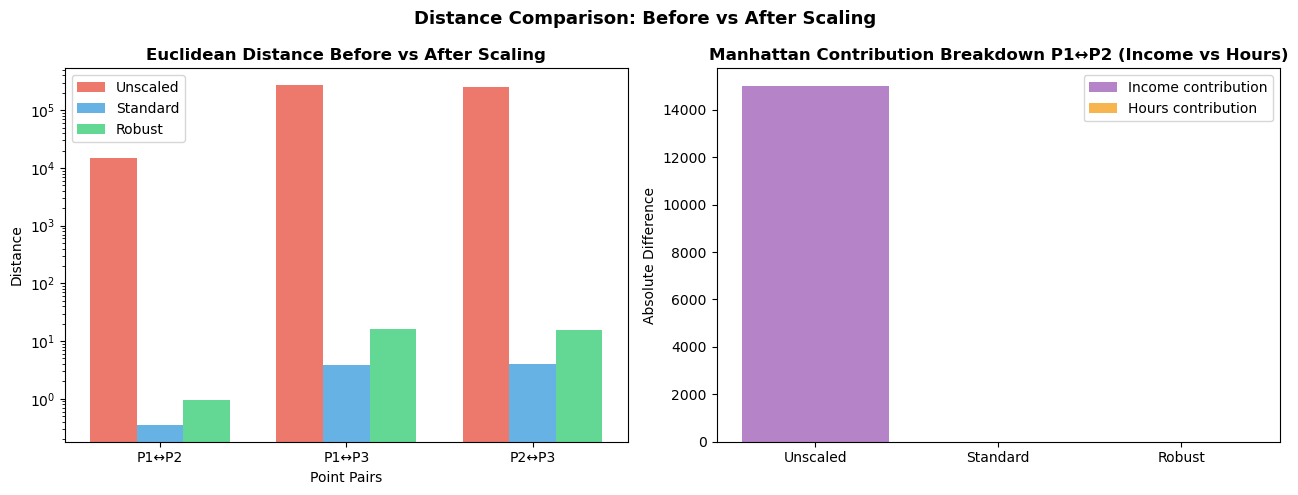

In [27]:
import matplotlib.pyplot as plt

# Now we'll create a grouped bar chart comparing distances across scalers
pair_names  = ['P1↔P2', 'P1↔P3', 'P2↔P3']
unscaled_e  = [euclidean(P1,P2),     euclidean(P1,P3),     euclidean(P2,P3)]
std_e       = [euclidean(P1_std,P2_std), euclidean(P1_std,P3_std), euclidean(P2_std,P3_std)]
robust_e    = [euclidean(P1_rob,P2_rob), euclidean(P1_rob,P3_rob), euclidean(P2_rob,P3_rob)]

x = np.arange(len(pair_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Euclidean
ax = axes[0]
ax.bar(x - width, unscaled_e, width, label='Unscaled',  color='#e74c3c', alpha=0.75)
ax.bar(x,          std_e,      width, label='Standard',  color='#3498db', alpha=0.75)
ax.bar(x + width,  robust_e,   width, label='Robust',    color='#2ecc71', alpha=0.75)
ax.set_xticks(x); ax.set_xticklabels(pair_names)
ax.set_title('Euclidean Distance Before vs After Scaling', fontweight='bold')
ax.set_ylabel('Distance'); ax.legend()
ax.set_yscale('log')
ax.set_xlabel('Point Pairs')

# Right: contribution breakdown for P1↔P2 before/after
labels  = ['Unscaled', 'Standard', 'Robust']
hours_c = [abs(P1[0]-P2[0]),         abs(P1_std[0]-P2_std[0]), abs(P1_rob[0]-P2_rob[0])]
gpa_c   = [abs(P1[1]-P2[1]),         abs(P1_std[1]-P2_std[1]), abs(P1_rob[1]-P2_rob[1])]

ax2 = axes[1]
ax2.bar(labels, hours_c, label='Income contribution', color='#9b59b6', alpha=0.75)
ax2.bar(labels, gpa_c,   bottom=hours_c, label='Hours contribution', color='#f39c12', alpha=0.75)
ax2.set_title('Manhattan Contribution Breakdown P1↔P2 (Income vs Hours)', fontweight='bold')
ax2.set_ylabel('Absolute Difference'); ax2.legend()

plt.suptitle('Distance Comparison: Before vs After Scaling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
# Here we've plotted distance comparison and contribution breakdown side by side.


**Left chart (log scale):** Unscaled distance অনেক বড় — log scale না দিলে scaled bar দেখাই যেত না।

**Right chart:** Unscaled-এ Income প্রায় সব contribution নিয়ে নেয়। Scaling-এর পরে Income ও Hours balanced।


---